# Breast Cancer Dataset — Full Pipeline
**Preprocessing → EDA → PCA Extraction → ANOVA Feature Selection → KNN → SVM → Logistic Regression**

Dataset: Wisconsin Breast Cancer (569 samples, 30 numeric features, target = `diagnosis` [B/M])

Place `breast-cancer.csv` in the same folder as this notebook before running.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                              roc_curve, auc, precision_recall_curve)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

RANDOM_STATE = 42
pd.set_option('display.max_columns', 40)

## Step 1 — Load data

In [2]:
df = pd.read_csv('breast-cancer.csv')
print("Shape:", df.shape)
df.head()

Shape: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Step 2 — Cleaning
- Drop `id` (no predictive value)
- Drop any fully-empty columns
- Check / remove missing values and duplicate rows

In [3]:
df = df.drop(columns=['id'])
df = df.dropna(axis=1, how='all')

print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()
print("Shape after cleaning:", df.shape)

Missing values: 0
Duplicate rows: 0
Shape after cleaning: (569, 31)


## Step 3 — Encode target (`diagnosis`: B=0, M=1)

In [4]:
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])
print(dict(zip(le.classes_, le.transform(le.classes_))))
df['diagnosis'].value_counts()

{'B': np.int64(0), 'M': np.int64(1)}


diagnosis
0    357
1    212
Name: count, dtype: int64

## Step 4 — Exploratory Data Analysis (EDA)
Descriptive statistics, class balance, feature distributions, and correlations — before any modeling.

### 4.1 Descriptive statistics

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
diagnosis,569.0,0.372583,0.483918,0.000000,0.000000,0.000000,1.000000,1.00000
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400


### 4.2 Class distribution

/tmp/ipykernel_122/2931950073.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df['diagnosis'].map({0:'B (Benign)', 1:'M (Malignant)'}), palette=['#55A868','#C44E52'])


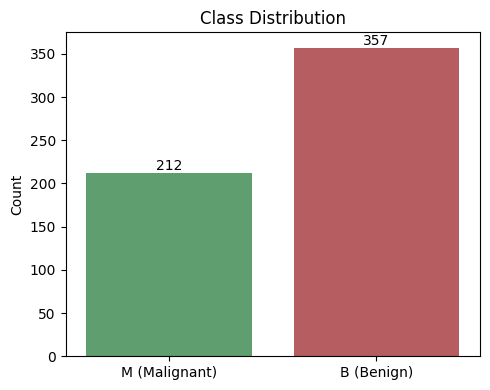

In [6]:
plt.figure(figsize=(5,4))
ax = sns.countplot(x=df['diagnosis'].map({0:'B (Benign)', 1:'M (Malignant)'}), palette=['#55A868','#C44E52'])
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.title('Class Distribution'); plt.xlabel(''); plt.ylabel('Count')
plt.tight_layout(); plt.show()

### 4.3 Feature distributions by class
Histograms (with KDE) for the key `_mean` features, split by diagnosis — shows how well each separates B vs M.

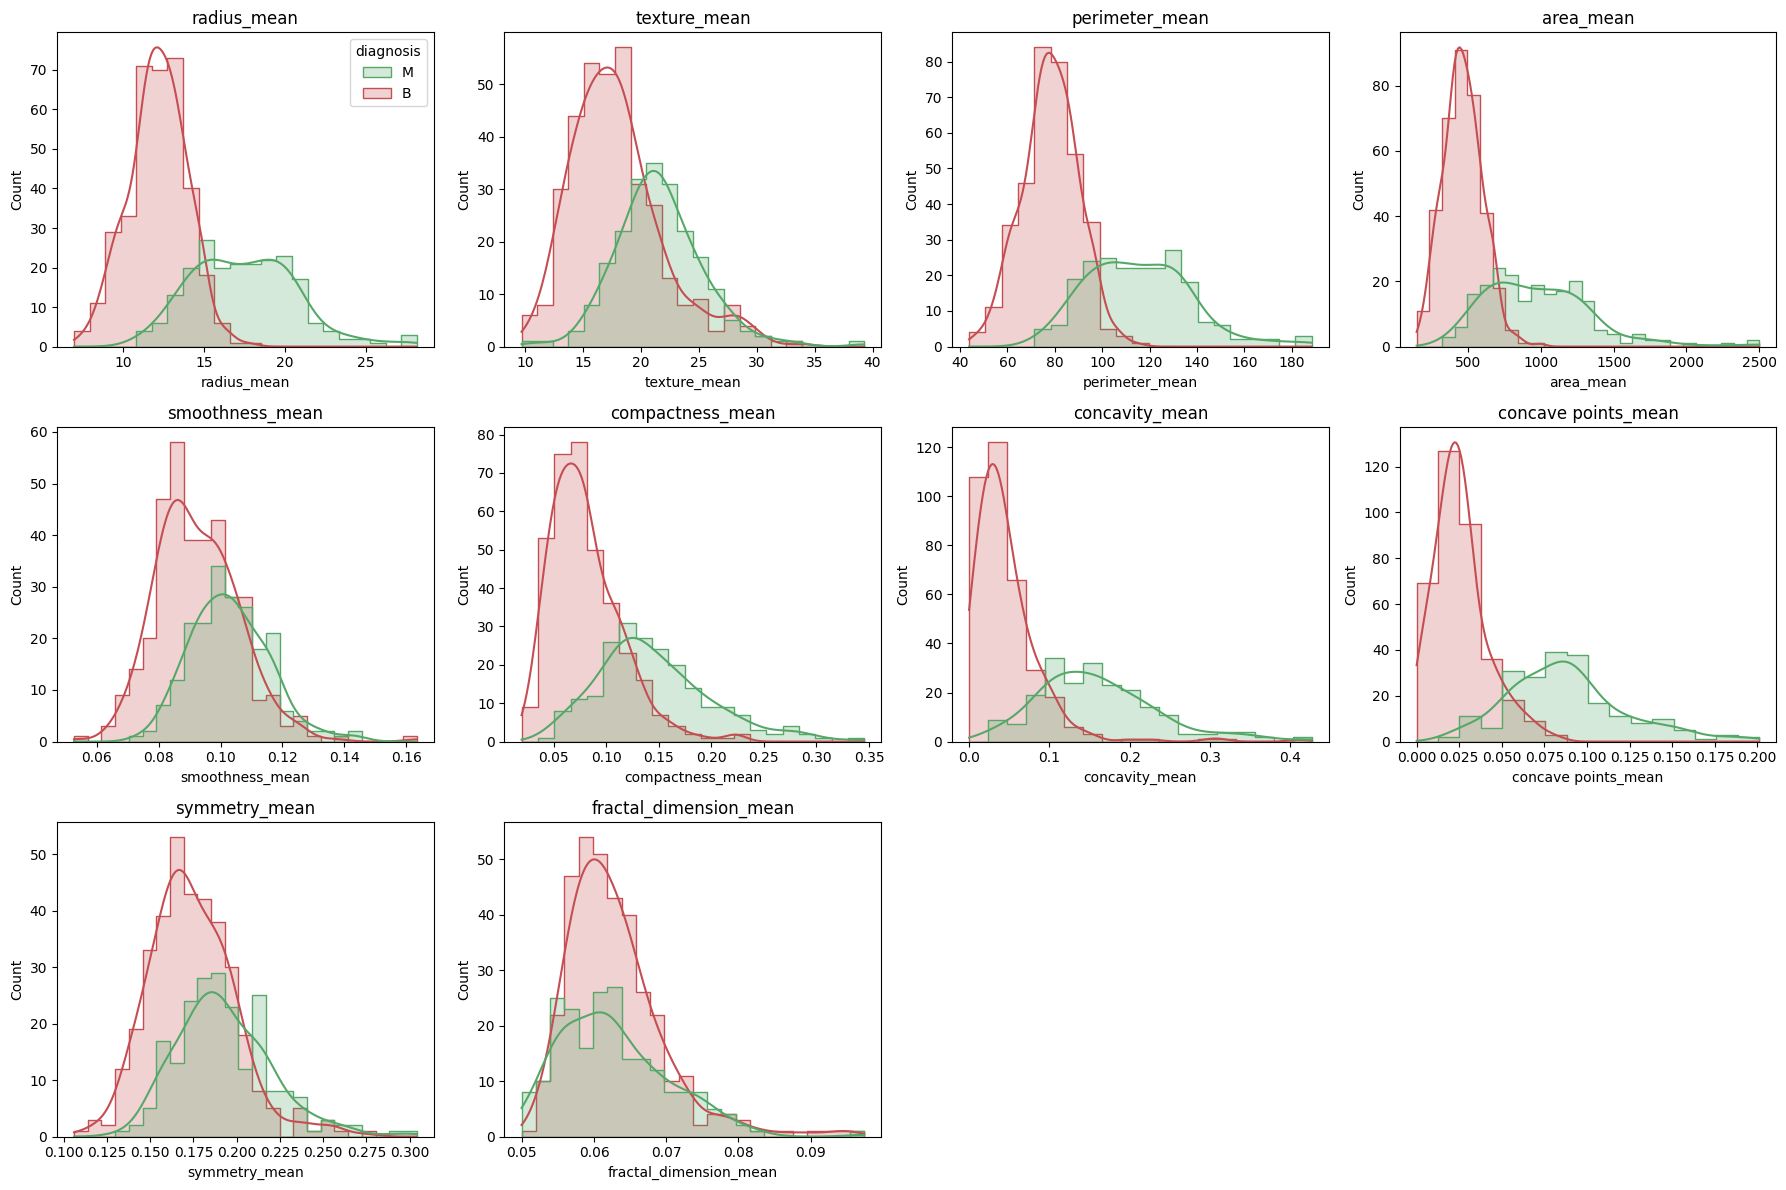

In [7]:
mean_feats = [c for c in df.columns if c.endswith('_mean')]
fig, axes = plt.subplots(3, 4, figsize=(18,12))
axes = axes.flatten()
for i, col in enumerate(mean_feats):
    sns.histplot(data=df, x=col, hue=df['diagnosis'].map({0:'B',1:'M'}), kde=True, ax=axes[i],
                 palette=['#55A868','#C44E52'], element='step', legend=(i==0))
    axes[i].set_title(col)
for j in range(len(mean_feats), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout(); plt.show()

### 4.4 Boxplots — spread and outliers per class

/tmp/ipykernel_122/3494730776.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=df['diagnosis'].map({0:'B',1:'M'}), y=col, ax=axes[i], palette=['#55A868','#C44E52'])
/tmp/ipykernel_122/3494730776.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=df['diagnosis'].map({0:'B',1:'M'}), y=col, ax=axes[i], palette=['#55A868','#C44E52'])
/tmp/ipykernel_122/3494730776.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=df['diagnosis'].map({0:'B',1:'M'}), y=col, ax=axes[i], palette=['#55A868','#C44E52'])
/tmp/ipyke

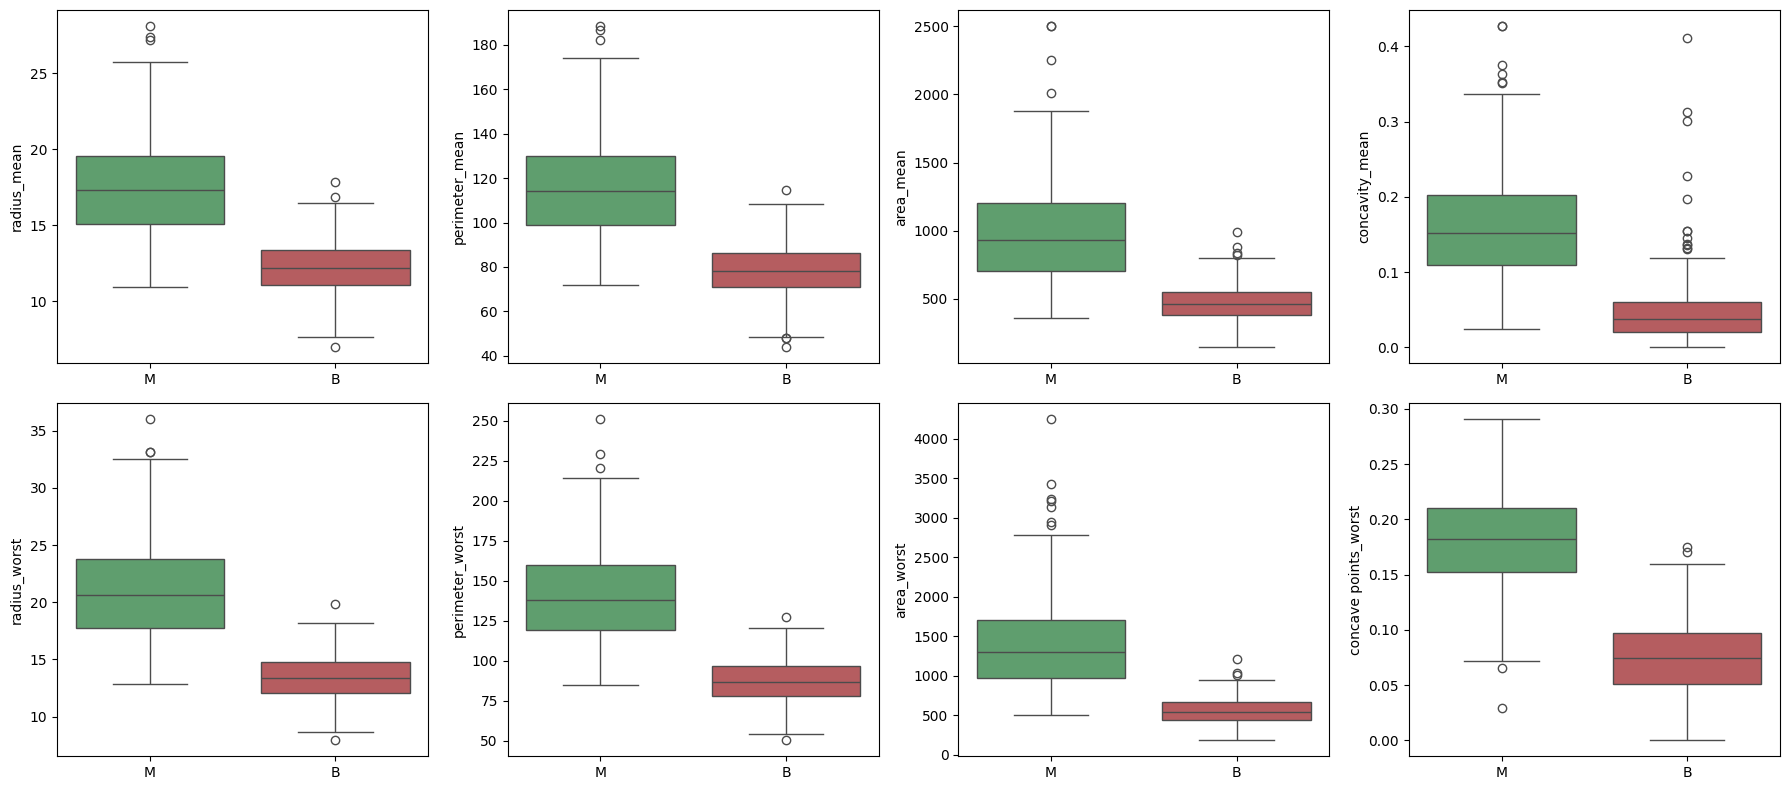

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(18,8))
axes = axes.flatten()
top_feats = ['radius_mean','perimeter_mean','area_mean','concavity_mean',
             'radius_worst','perimeter_worst','area_worst','concave points_worst']
for i, col in enumerate(top_feats):
    sns.boxplot(data=df, x=df['diagnosis'].map({0:'B',1:'M'}), y=col, ax=axes[i], palette=['#55A868','#C44E52'])
    axes[i].set_xlabel('')
plt.tight_layout(); plt.show()

### 4.5 Correlation heatmap — all features + target

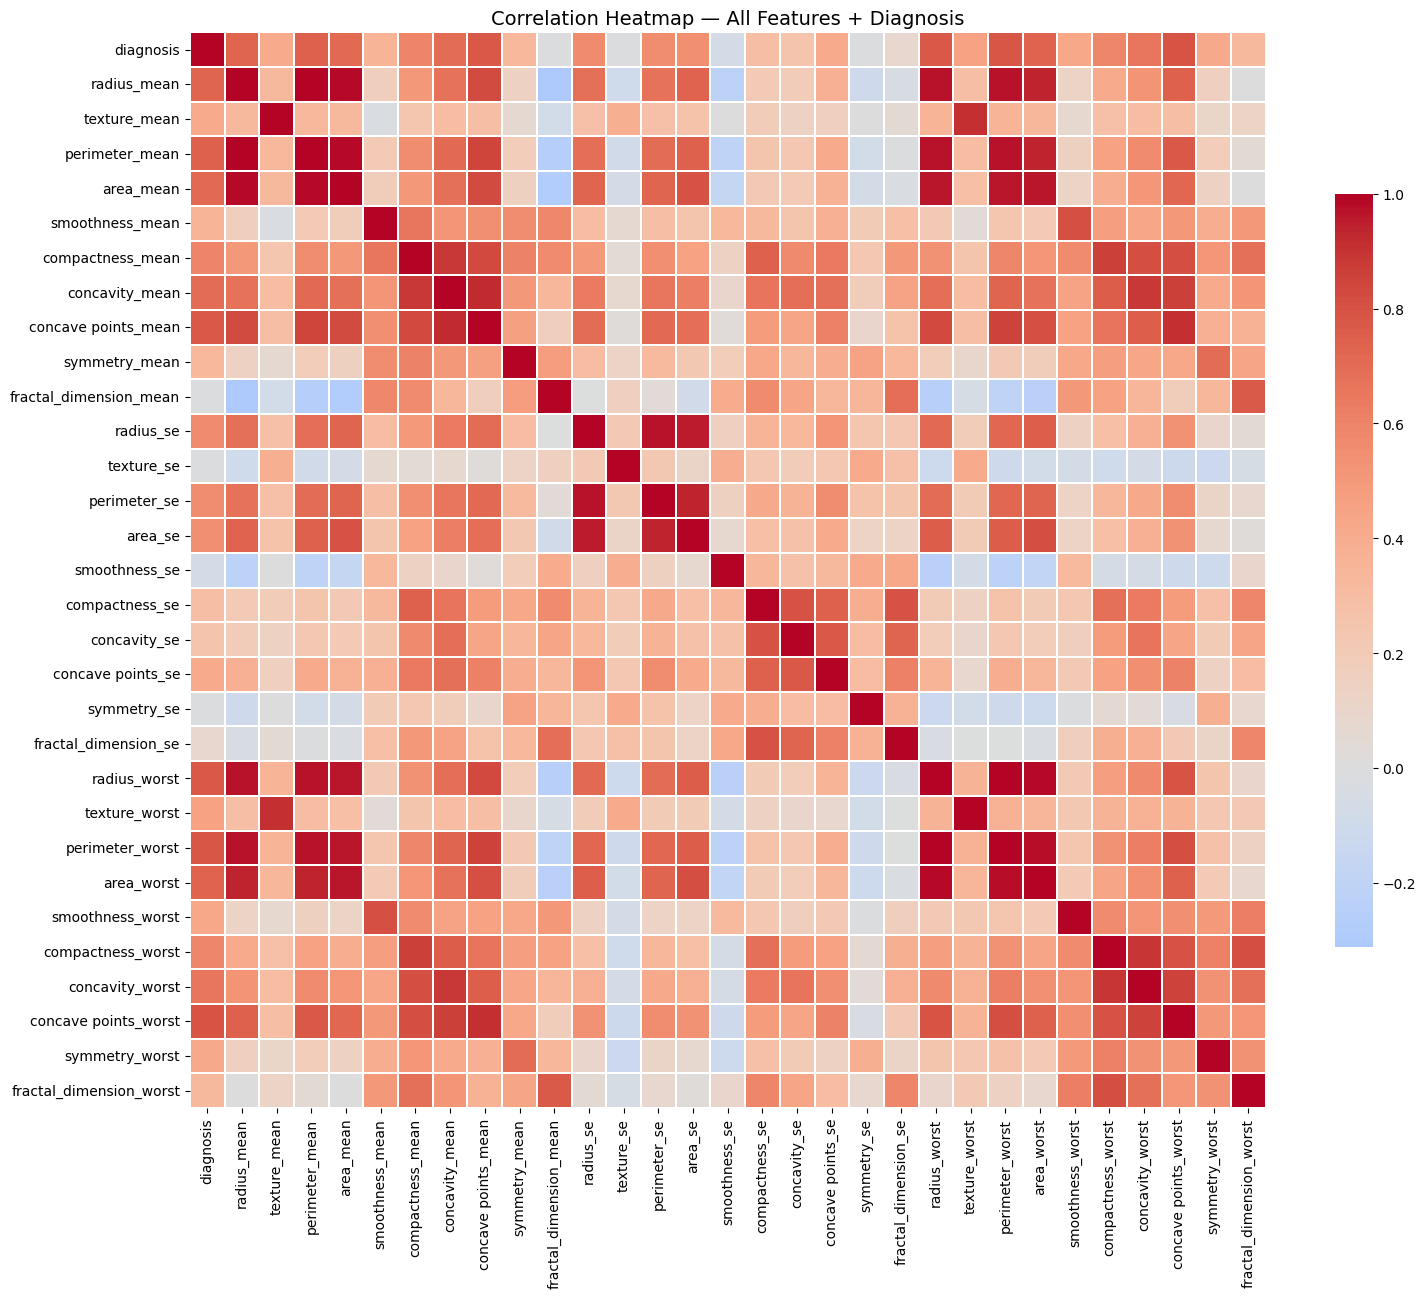

In [9]:
plt.figure(figsize=(16,13))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, square=True,
            cbar_kws={'shrink': 0.7}, linewidths=0.3)
plt.title('Correlation Heatmap — All Features + Diagnosis', fontsize=14)
plt.tight_layout(); plt.show()

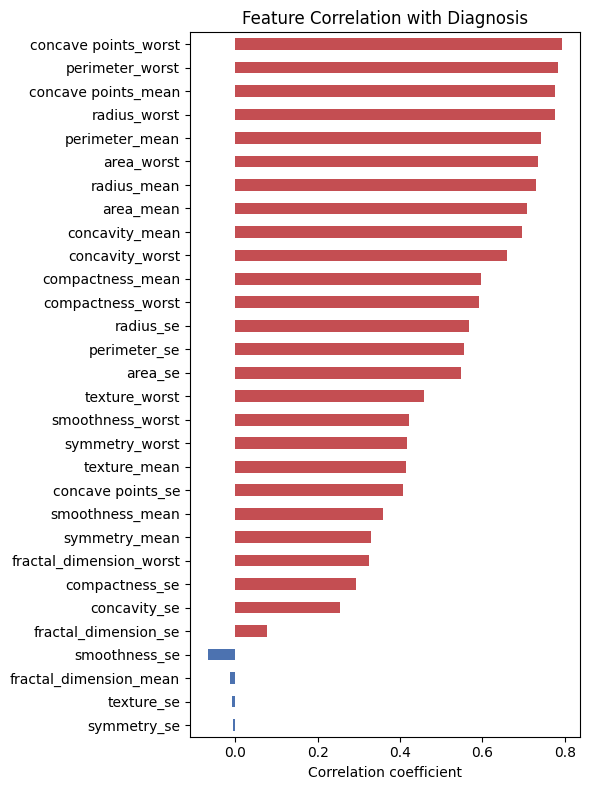

Feature pairs with |correlation| > 0.9: 21


radius_mean      perimeter_mean     0.997855
radius_worst     perimeter_worst    0.993708
radius_mean      area_mean          0.987357
perimeter_mean   area_mean          0.986507
radius_worst     area_worst         0.984015
perimeter_worst  area_worst         0.977578
radius_se        perimeter_se       0.972794
perimeter_mean   perimeter_worst    0.970387
radius_mean      radius_worst       0.969539
perimeter_mean   radius_worst       0.969476
radius_mean      perimeter_worst    0.965137
area_mean        radius_worst       0.962746
                 area_worst         0.959213
                 perimeter_worst    0.959120
radius_se        area_se            0.951830
dtype: float64

In [10]:
feature_cols = [c for c in df.columns if c != 'diagnosis']

# Features most correlated with the target
target_corr = corr['diagnosis'].drop('diagnosis').sort_values(key=abs, ascending=False)
plt.figure(figsize=(6,8))
target_corr.plot(kind='barh', color=np.where(target_corr > 0, '#C44E52', '#4C72B0'))
plt.title('Feature Correlation with Diagnosis'); plt.xlabel('Correlation coefficient')
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()

# Highly correlated feature pairs (potential redundancy, |r| > 0.9, excluding target)
feat_corr = df[feature_cols].corr().abs()
pairs = feat_corr.where(np.triu(np.ones(feat_corr.shape), k=1).astype(bool)).stack()
high_corr_pairs = pairs[pairs > 0.9].sort_values(ascending=False)
print(f"Feature pairs with |correlation| > 0.9: {len(high_corr_pairs)}")
high_corr_pairs.head(15)

## Step 5 — Outlier check (IQR method)
Reported only — **not removed**: in medical data, extreme tumor measurements are usually real clinical signal, not noise.

In [11]:
outlier_counts = {}
for col in feature_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outlier_counts[col] = int(((df[col] < lower) | (df[col] > upper)).sum())

pd.Series(outlier_counts).sort_values(ascending=False).head(10)

area_se                    65
radius_se                  38
perimeter_se               38
area_worst                 35
smoothness_se              30
fractal_dimension_se       28
compactness_se             28
symmetry_se                27
area_mean                  25
fractal_dimension_worst    24
dtype: int64

## Step 6 — Train / test split (80/20, stratified)

In [12]:
X = df[feature_cols]
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (455, 30)  Test: (114, 30)


## Step 7 — Scaling (StandardScaler, fit on train only — avoids data leakage)

In [13]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols, index=X_test.index)
X_train_scaled.describe().T[['mean','std']].head()

,mean,std
radius_mean,-1.737316e-16,1.001101
texture_mean,3.904081e-16,1.001101
perimeter_mean,4.704418e-16,1.001101
area_mean,-1.171224e-16,1.001101
smoothness_mean,7.242070e-16,1.001101


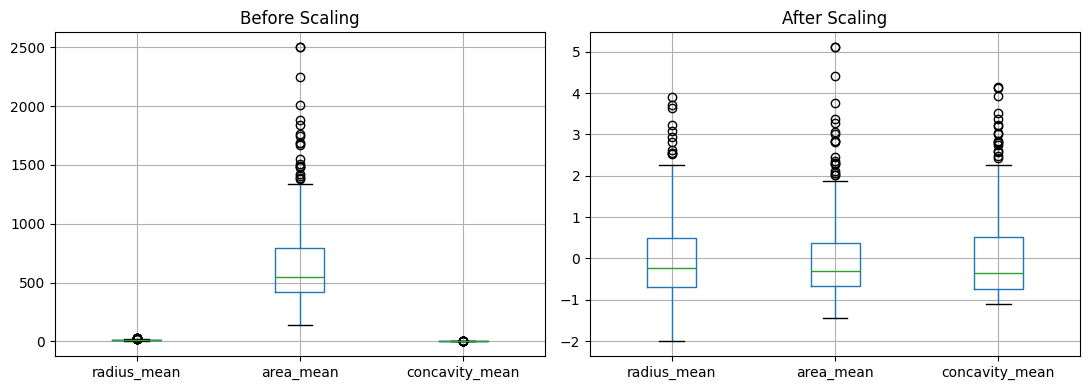

In [14]:
# Before vs after scaling (sample of features), sanity check
sample_feats = ['radius_mean', 'area_mean', 'concavity_mean']
fig, axes = plt.subplots(1, 2, figsize=(11,4))
X_train[sample_feats].boxplot(ax=axes[0]); axes[0].set_title('Before Scaling')
X_train_scaled[sample_feats].boxplot(ax=axes[1]); axes[1].set_title('After Scaling')
plt.tight_layout(); plt.show()

## Step 8 — Feature Extraction (PCA)
Exploratory: how many principal components are needed to capture 95% of the variance?

Components needed for 95% variance: 10
Explained variance ratio (cumulative): 0.9520691014391005


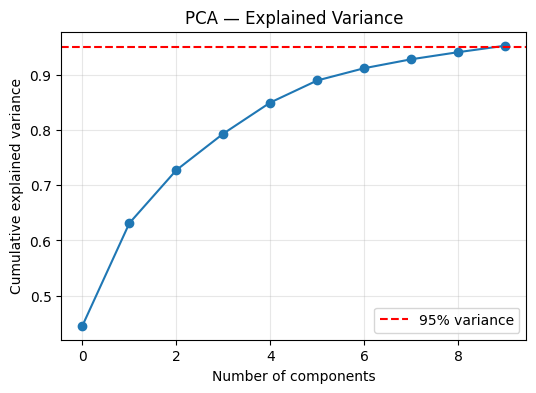

In [15]:
pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Components needed for 95% variance:", pca.n_components_)
print("Explained variance ratio (cumulative):", pca.explained_variance_ratio_.cumsum()[-1])

plt.figure(figsize=(6,4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.axhline(0.95, color='r', linestyle='--', label='95% variance')
plt.xlabel('Number of components'); plt.ylabel('Cumulative explained variance')
plt.title('PCA — Explained Variance'); plt.legend(); plt.grid(alpha=0.3)
plt.show()

## Step 9 — Feature Selection (ANOVA F-test / `SelectKBest`)
Selecting the top 15 original features most correlated with `diagnosis` (kept separate from PCA to preserve interpretability).

In [16]:
K = 15
selector = SelectKBest(score_func=f_classif, k=K)
X_train_sel = selector.fit_transform(X_train_scaled, y_train)
X_test_sel = selector.transform(X_test_scaled)

selected_mask = selector.get_support()
selected_features = list(np.array(feature_cols)[selected_mask])
anova_scores = pd.Series(selector.scores_, index=feature_cols).sort_values(ascending=False)

print("Selected features:", selected_features)
anova_scores.head(15)

Selected features: [np.str_('radius_mean'), np.str_('perimeter_mean'), np.str_('area_mean'), np.str_('compactness_mean'), np.str_('concavity_mean'), np.str_('concave points_mean'), np.str_('radius_se'), np.str_('perimeter_se'), np.str_('area_se'), np.str_('radius_worst'), np.str_('perimeter_worst'), np.str_('area_worst'), np.str_('compactness_worst'), np.str_('concavity_worst'), np.str_('concave points_worst')]


concave points_worst    733.724933
perimeter_worst         717.246487
radius_worst            692.861395
concave points_mean     684.526845
perimeter_mean          548.413236
area_worst              522.188947
radius_mean             511.274848
area_mean               444.857518
concavity_mean          397.592082
concavity_worst         319.507776
compactness_mean        263.564326
compactness_worst       238.203725
radius_se               205.433206
perimeter_se            193.168931
area_se                 180.561229
dtype: float64

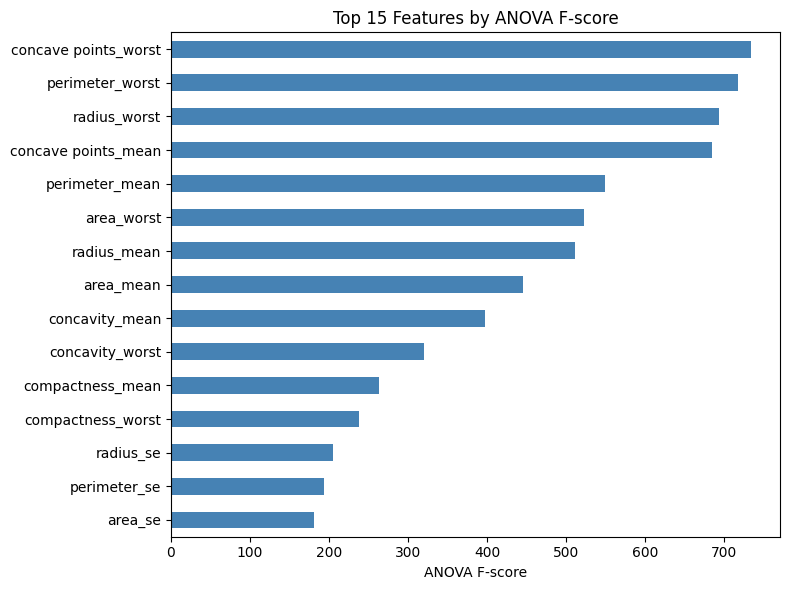

In [17]:
plt.figure(figsize=(8,6))
anova_scores.head(15).sort_values().plot(kind='barh', color='steelblue')
plt.xlabel('ANOVA F-score'); plt.title('Top 15 Features by ANOVA F-score')
plt.tight_layout(); plt.show()

### Heatmap of the ANOVA-selected features only
Zoomed-in correlation view for just the 15 chosen features.

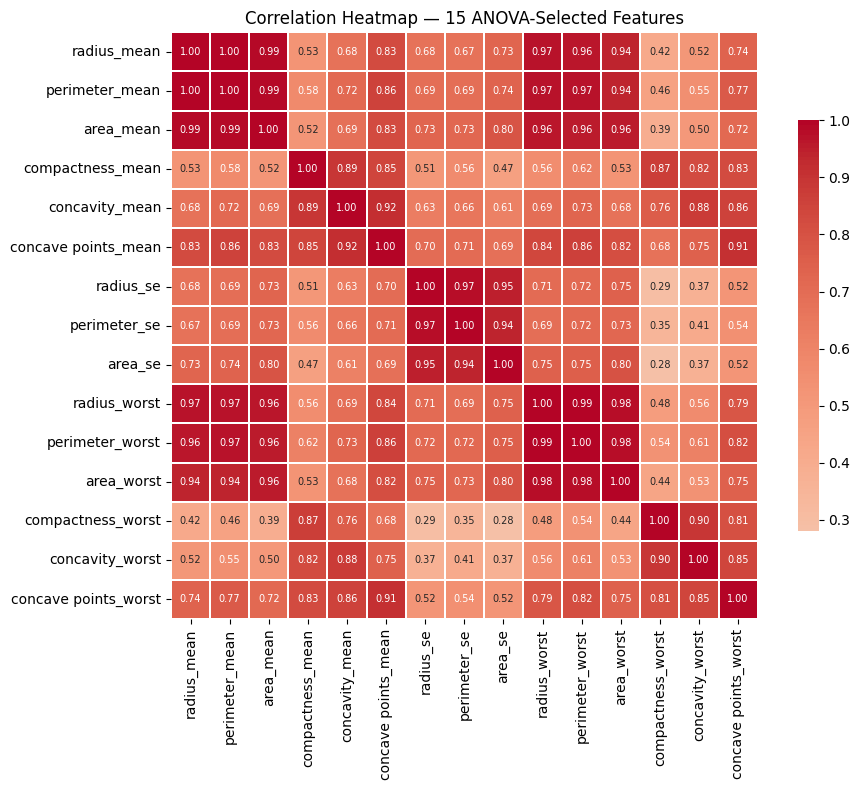

In [18]:
plt.figure(figsize=(10,8))
sel_corr = X_train_scaled[selected_features].corr()
sns.heatmap(sel_corr, cmap='coolwarm', center=0, annot=True, fmt='.2f', square=True,
            cbar_kws={'shrink': 0.7}, linewidths=0.3, annot_kws={'size':7})
plt.title('Correlation Heatmap — 15 ANOVA-Selected Features')
plt.tight_layout(); plt.show()

## Step 10 — Model 1: KNN
Hyperparameter tuning via `GridSearchCV` (5-fold CV) on the ANOVA-selected features.

In [19]:
knn_param_grid = {'n_neighbors': list(range(3, 16, 2)), 'weights': ['uniform', 'distance']}
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_param_grid, cv=5, scoring='accuracy')
knn_grid.fit(X_train_sel, y_train)

knn_best = knn_grid.best_estimator_
knn_pred = knn_best.predict(X_test_sel)
knn_proba = knn_best.predict_proba(X_test_sel)[:,1]
knn_acc = accuracy_score(y_test, knn_pred)

print("Best params:", knn_grid.best_params_)
print("CV accuracy:", knn_grid.best_score_)
print("Test accuracy:", knn_acc)
print(classification_report(y_test, knn_pred, target_names=le.classes_))

Best params: {'n_neighbors': 9, 'weights': 'uniform'}
CV accuracy: 0.9362637362637363
Test accuracy: 0.9385964912280702
              precision    recall  f1-score   support

           B       0.92      0.99      0.95        72
           M       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



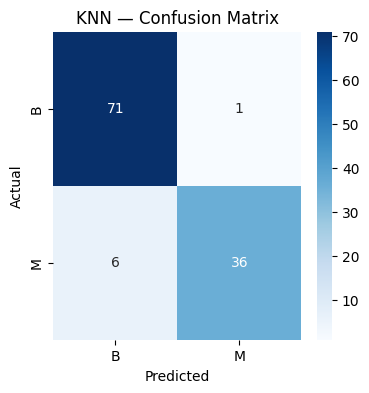

In [20]:
plt.figure(figsize=(4,4))
sns.heatmap(confusion_matrix(y_test, knn_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('KNN — Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()

## Step 11 — Model 2: SVM
Hyperparameter tuning via `GridSearchCV` (5-fold CV) — kernel, `C`, `gamma`.

In [21]:
svm_param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear']
}
svm_grid = GridSearchCV(SVC(probability=True, random_state=RANDOM_STATE), svm_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
svm_grid.fit(X_train_sel, y_train)

svm_best = svm_grid.best_estimator_
svm_pred = svm_best.predict(X_test_sel)
svm_proba = svm_best.predict_proba(X_test_sel)[:,1]
svm_acc = accuracy_score(y_test, svm_pred)

print("Best params:", svm_grid.best_params_)
print("CV accuracy:", svm_grid.best_score_)
print("Test accuracy:", svm_acc)
print(classification_report(y_test, svm_pred, target_names=le.classes_))

Best params: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
CV accuracy: 0.9582417582417584
Test accuracy: 0.9649122807017544
              precision    recall  f1-score   support

           B       0.95      1.00      0.97        72
           M       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



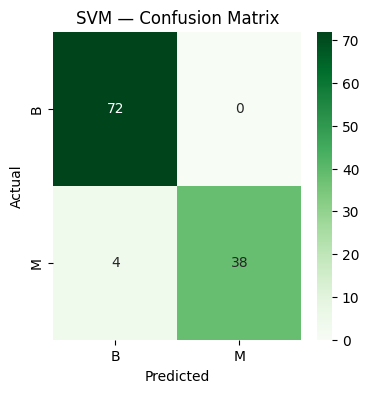

In [22]:
plt.figure(figsize=(4,4))
sns.heatmap(confusion_matrix(y_test, svm_pred), annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('SVM — Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()

## Step 12 — Model 3: Logistic Regression
Hyperparameter tuning via `GridSearchCV` (5-fold CV) — `C`, `penalty`.

In [23]:
logreg_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs']
}
logreg_grid = GridSearchCV(LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
                            logreg_param_grid, cv=5, scoring='accuracy')
logreg_grid.fit(X_train_sel, y_train)

logreg_best = logreg_grid.best_estimator_
logreg_pred = logreg_best.predict(X_test_sel)
logreg_proba = logreg_best.predict_proba(X_test_sel)[:,1]
logreg_acc = accuracy_score(y_test, logreg_pred)

print("Best params:", logreg_grid.best_params_)
print("CV accuracy:", logreg_grid.best_score_)
print("Test accuracy:", logreg_acc)
print(classification_report(y_test, logreg_pred, target_names=le.classes_))

Best params: {'C': 100, 'solver': 'lbfgs'}
CV accuracy: 0.945054945054945
Test accuracy: 0.9649122807017544
              precision    recall  f1-score   support

           B       0.96      0.99      0.97        72
           M       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



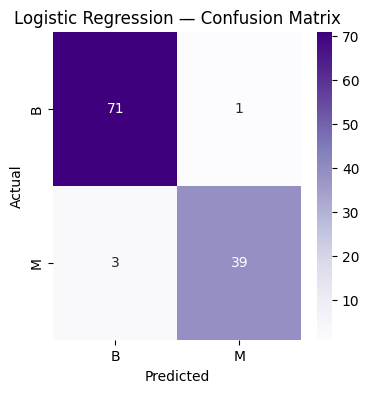

In [24]:
plt.figure(figsize=(4,4))
sns.heatmap(confusion_matrix(y_test, logreg_pred), annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Logistic Regression — Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()

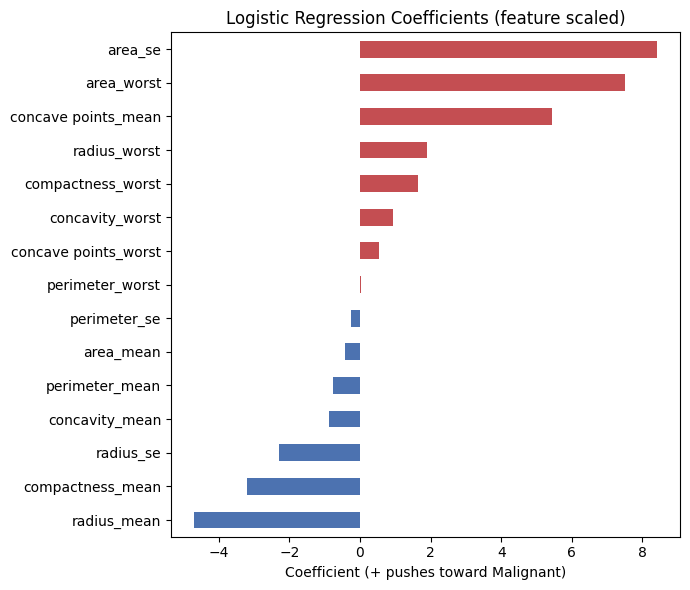

In [25]:
# Logistic Regression coefficients — which features push toward Malignant?
coefs = pd.Series(logreg_best.coef_[0], index=selected_features).sort_values()
plt.figure(figsize=(7,6))
coefs.plot(kind='barh', color=np.where(coefs > 0, '#C44E52', '#4C72B0'))
plt.title('Logistic Regression Coefficients (feature scaled)')
plt.xlabel('Coefficient (+ pushes toward Malignant)')
plt.tight_layout(); plt.show()

## Model comparison — KNN vs SVM vs Logistic Regression

In [26]:
comparison = pd.DataFrame({
    'Model': ['KNN', 'SVM', 'Logistic Regression'],
    'CV Accuracy': [knn_grid.best_score_, svm_grid.best_score_, logreg_grid.best_score_],
    'Test Accuracy': [knn_acc, svm_acc, logreg_acc]
})
comparison

,Model,CV Accuracy,Test Accuracy
0,KNN,0.936264,0.938596
1,SVM,0.958242,0.964912
2,Logistic Regression,0.945055,0.964912


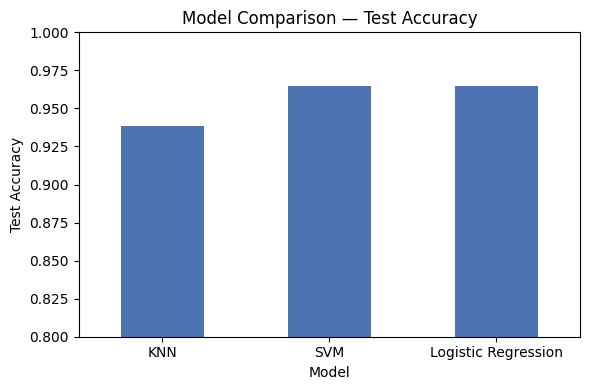

In [27]:
comparison.set_index('Model')[['Test Accuracy']].plot(kind='bar', legend=False,
    color=['#4C72B0','#55A868','#8172B2'], figsize=(6,4))
plt.ylabel('Test Accuracy'); plt.ylim(0.8, 1.0); plt.title('Model Comparison — Test Accuracy')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

### ROC Curves — all three models

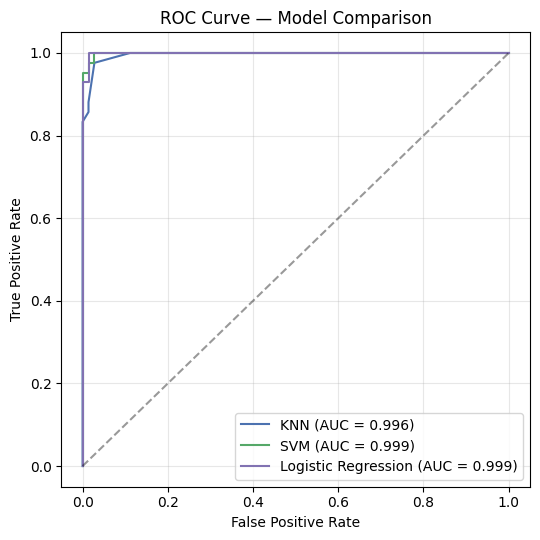

In [28]:
fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_proba)
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_proba)
fpr_lr, tpr_lr, _ = roc_curve(y_test, logreg_proba)
auc_knn, auc_svm, auc_lr = auc(fpr_knn, tpr_knn), auc(fpr_svm, tpr_svm), auc(fpr_lr, tpr_lr)

plt.figure(figsize=(5.5,5.5))
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.3f})', color='#4C72B0')
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.3f})', color='#55A868')
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})', color='#8172B2')
plt.plot([0,1], [0,1], 'k--', alpha=0.4)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Model Comparison'); plt.legend(loc='lower right'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Save outputs
- Final CSV: selected features + diagnosis + predictions from all three models (refit on full data)
- Trained models (`.pkl`) for reuse without retraining

In [29]:
X_full_scaled = pd.concat([X_train_scaled, X_test_scaled]).sort_index()
final_df = X_full_scaled[selected_features].copy()
final_df.insert(0, 'diagnosis_label', le.inverse_transform(df['diagnosis']))
final_df['diagnosis'] = df['diagnosis'].values

knn_full = KNeighborsClassifier(**knn_grid.best_params_).fit(final_df[selected_features], final_df['diagnosis'])
svm_full = SVC(**svm_grid.best_params_, probability=True, random_state=RANDOM_STATE).fit(final_df[selected_features], final_df['diagnosis'])
logreg_full = LogisticRegression(**logreg_grid.best_params_, max_iter=5000, random_state=RANDOM_STATE).fit(final_df[selected_features], final_df['diagnosis'])


final_df['knn_predicted_diagnosis'] = np.where(knn_full.predict(final_df[selected_features]) == 1, 'M', 'B')
final_df['svm_predicted_diagnosis'] = np.where(svm_full.predict(final_df[selected_features]) == 1, 'M', 'B')
final_df['logreg_predicted_diagnosis'] = np.where(logreg_full.predict(final_df[selected_features]) == 1, 'M', 'B')

final_df.to_csv('breast_cancer_final_with_svm.csv', index=False)
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(selector, 'selector.pkl')
joblib.dump(knn_full, 'knn_model_final.pkl')
joblib.dump(svm_full, 'svm_model_final.pkl')
joblib.dump(logreg_full, 'logreg_model_final.pkl')

print("Saved: breast_cancer_final_with_svm.csv")
final_df.head()

Saved: breast_cancer_final_with_svm.csv


,diagnosis_label,radius_mean,perimeter_mean,area_mean,compactness_mean,concavity_mean,concave points_mean,radius_se,perimeter_se,area_se,radius_worst,perimeter_worst,area_worst,compactness_worst,concavity_worst,concave points_worst,diagnosis,knn_predicted_diagnosis,svm_predicted_diagnosis,logreg_predicted_diagnosis
0,M,1.069585,1.238728,0.948335,3.226779,2.584493,2.474259,2.359083,2.677043,2.319856,1.844186,2.247892,1.939865,2.591678,2.061687,2.245147,1,M,M,M
1,M,1.791234,1.647802,1.851056,-0.467863,-0.027991,0.533657,0.456465,0.229364,0.678672,1.764523,1.492145,1.831563,-0.435640,-0.158457,1.055997,1,M,M,M
2,M,1.545090,1.530345,1.509411,1.041117,1.326040,1.989928,1.153690,0.789062,1.091451,1.474470,1.307603,1.406949,1.067907,0.827225,1.909669,1,M,M,M
3,M,-0.768102,-0.592787,-0.759615,3.343769,1.865202,1.417308,0.291215,0.251525,-0.290685,-0.294448,-0.263354,-0.555039,3.860118,1.943670,2.126831,1,M,M,M
4,M,1.712916,1.736907,1.770506,0.537876,1.333392,1.394605,1.193708,1.191272,1.099934,1.264079,1.298815,1.176592,-0.319350,0.589302,0.704044,1,M,M,M


## Summary
| Stage | Result |
|---|---|
| Rows / Features | 569 / 30 (no missing values, no duplicates) |
| Selected features (ANOVA) | 15 (top: `concave points_worst`, `perimeter_worst`, `radius_worst`, ...) |
| Models trained | KNN, SVM, Logistic Regression (all tuned via `GridSearchCV`) |
| Comparison | see `comparison` table and ROC curve above |
| Outputs | `breast_cancer_final_with_svm.csv`, `knn_model_final.pkl`, `svm_model_final.pkl`, `logreg_model_final.pkl` |